In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: EfficientNetV2B2 + Triplet Loss - 204 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 204 (range=(0, 204))
- Architecture: EfficientNetV2B2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns
import cv2
import yaml

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 147.2 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=2f975cf541409721fef58d66611aeef3ec2688739c5b4f3590b6a37b8948ae01
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


## Configuration

Configuration is split into dataclasses by domain of responsibility:

- ModelConfig - siamese network type (pair o triplet)
- `DataConfig` - selected authors and image shapes
- TrainingConfig - training hyperparameters
- BatchConfig - batch sizes per split

**Key decisions**:
- val_ratio=0.25 - fraction on non-test data reserved for validation
- epochs=50 - maximum training epochs (early stopping may trigger earlier)

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
def load_config(path: str) -> Config:
  with open(path, "r") as f:
      cfg_dict = yaml.safe_load(f)

  authors_cfg = cfg_dict["data"]["authors_range"]

  return Config(
        project_path=cfg_dict["project_path"],
        dataset=cfg_dict["dataset"],
        model=ModelConfig(**cfg_dict["model"]),
        data=DataConfig(
            authors_range=range(authors_cfg["start"], authors_cfg["end"]),
            original_shape=tuple(cfg_dict["data"]["original_shape"]),
            model_input_shape=tuple(cfg_dict["data"]["model_input_shape"]),
        ),
        training=TrainingConfig(**cfg_dict["training"]),
        batch=BatchConfig(**cfg_dict["batch"]),
        current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
    )

In [6]:
config = load_config(path="drive/MyDrive/author-handwriting-recog/config/test_204_4.yaml")

In [7]:
def display_output(path: str):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    plt.figure(figsize=(w/100, h/100), dpi=100)
    plt.imshow(img, interpolation='nearest')
    plt.axis("off")
    plt.show()

In [8]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [9]:
def upload_file_to_source(source_file: str, dest_folder: str):
    os.makedirs(dest_folder, exist_ok=True)

    shutil.copy2(source_file, dest_folder)

In [10]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [11]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/180_360_90/{config.dataset}.tar.gz",
    dest_folder=f"./dataset"
)

In [12]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/experiments/efficientnet_204/siamese_model_204_20260407-191343.keras",
    dest_folder="./models"
)

In [71]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments/efficientnet_204/outputs",
    source_dest="./outputs"
)

In [14]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [15]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [16]:
from src.models import (
    EfficientNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [17]:
from src.evaluator.embedding_utils import EmbeddingExtractor, UMAPReducer
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [18]:
logger = LoggerFactory.get_logger(
    "efficient_test_204_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"efficient_triplet_{config.current_time}"
)

In [19]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [20]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [21]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [22]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

11:28:24 - efficient_test_204_4 - INFO - Total patches selected: 128891
11:28:24 - efficient_test_204_4 - INFO - Train: 96668 | Val: 32223 | Test: 8946
11:28:24 - efficient_test_204_4 - INFO - Avg non_test patches per author: 631.82 | Min: 142 | Max: 911
11:28:24 - efficient_test_204_4 - INFO - Avg test patches per author: 43.85 | Min: 22 | Max: 49
11:28:24 - efficient_test_204_4 - INFO - Image shape: (180, 360)
11:28:24 - efficient_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> efficientnet_preprocess at the end is required - it normalizes pixel values to the range expected by EfficientNetV2 (ImageNet statistics)

In [23]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.efficientnet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.efficientnet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [24]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [25]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [24]:
display_generator_info(train_triplet)

19:15:05 - efficient_test_204_4 - INFO - Generator: TripletGenerator
19:15:05 - efficient_test_204_4 - INFO - Number of samples: 96668
19:15:05 - efficient_test_204_4 - INFO - Batch size: 64
19:15:05 - efficient_test_204_4 - INFO - Steps per epoch: 1511
19:15:05 - efficient_test_204_4 - INFO - Shape: (180, 360)
19:15:05 - efficient_test_204_4 - INFO - Number of authors: 204


In [25]:
display_generator_info(val_triplet)

19:15:05 - efficient_test_204_4 - INFO - Generator: TripletGenerator
19:15:05 - efficient_test_204_4 - INFO - Number of samples: 32223
19:15:05 - efficient_test_204_4 - INFO - Batch size: 32
19:15:05 - efficient_test_204_4 - INFO - Steps per epoch: 1007
19:15:05 - efficient_test_204_4 - INFO - Shape: (180, 360)
19:15:05 - efficient_test_204_4 - INFO - Number of authors: 204


In [26]:
display_generator_info(test_triplet)

19:15:05 - efficient_test_204_4 - INFO - Generator: TripletGenerator
19:15:05 - efficient_test_204_4 - INFO - Number of samples: 8946
19:15:05 - efficient_test_204_4 - INFO - Batch size: 16
19:15:05 - efficient_test_204_4 - INFO - Steps per epoch: 560
19:15:05 - efficient_test_204_4 - INFO - Shape: (180, 360)
19:15:05 - efficient_test_204_4 - INFO - Number of authors: 204


## Model Construction

The architecture follows a chain of separated responsibilities:

```
EfficientNetV2Backbone      → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [26]:
embedding_network = EmbeddingNetwork(
    backbone=EfficientNetV2Backbone(variant="B2", freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [27]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [28]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [29]:
trainer.initialize_model()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


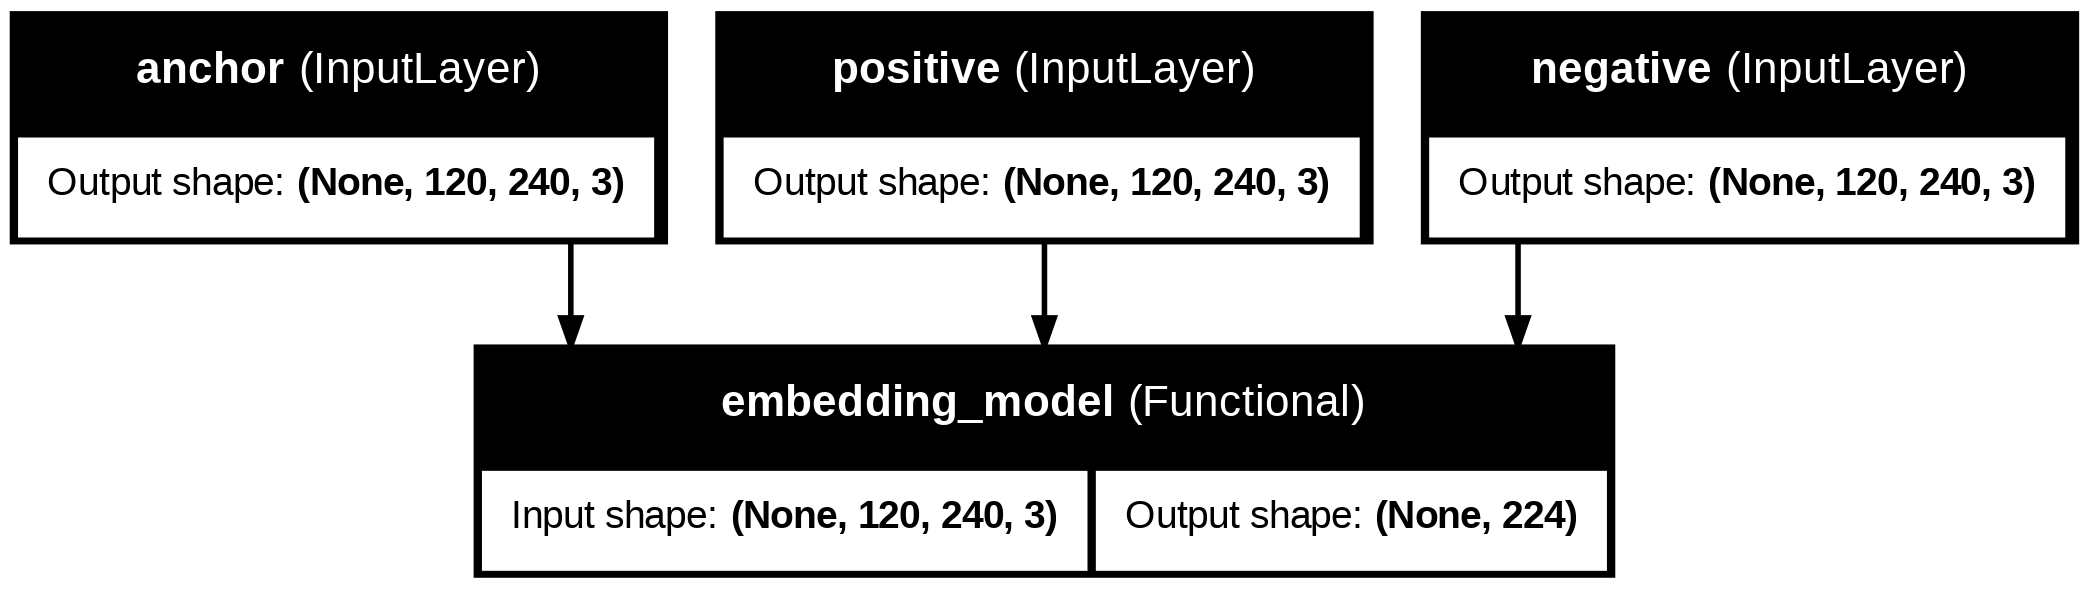

In [31]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [32]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  9,503,870 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,503,870 (36.25 MB)

 Trainable params: 8,699,340 (33.19 MB)

 Non-trainable params: 804,530 (3.07 MB)

In [33]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)  │ (None, 4, 8, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │       631,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,503,870 (36.25 MB)

 Trainable params: 8,699,340 (33.19 MB)

 Non-trainable params: 804,530 (3.07 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [30]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [35]:
callbacks = get_default_callbacks(
    model_name="efficient_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [36]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - an_sim: 1.1372e-04 - ap_sim: 0.0514 - loss: 0.3537 - margin: 0.0512 - triplet_acc: 0.6058
Epoch 1: val_loss improved from None to 0.23311, saving model to checkpoints/efficient_siamese_triplet/best.weights.h5

Epoch 1: finished saving model to checkpoints/efficient_siamese_triplet/best.weights.h5
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 808s 407ms/step - an_sim: 3.9592e-04 - ap_sim: 0.1060 - loss: 0.3157 - margin: 0.1056 - triplet_acc: 0.6575 - val_an_sim: 0.0274 - val_ap_sim: 0.2795 - val_loss: 0.2331 - val_margin: 0.2521 - val_triplet_acc: 0.7564 - learning_rate: 1.0000e-05
Epoch 2/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - an_sim: 0.0026 - ap_sim: 0.2720 - loss: 0.2321 - margin: 0.2694 - triplet_acc: 0.7530
Epoch 2: val_loss improved from 0.23311 to 0.18660, saving model to checkpoints/efficient_siamese_triplet/best.weights.h5

Epoch 2: finished saving model to checkpoints/efficient_siamese_triplet/best.weights.h5
1511/1511 ━━━━

In [37]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

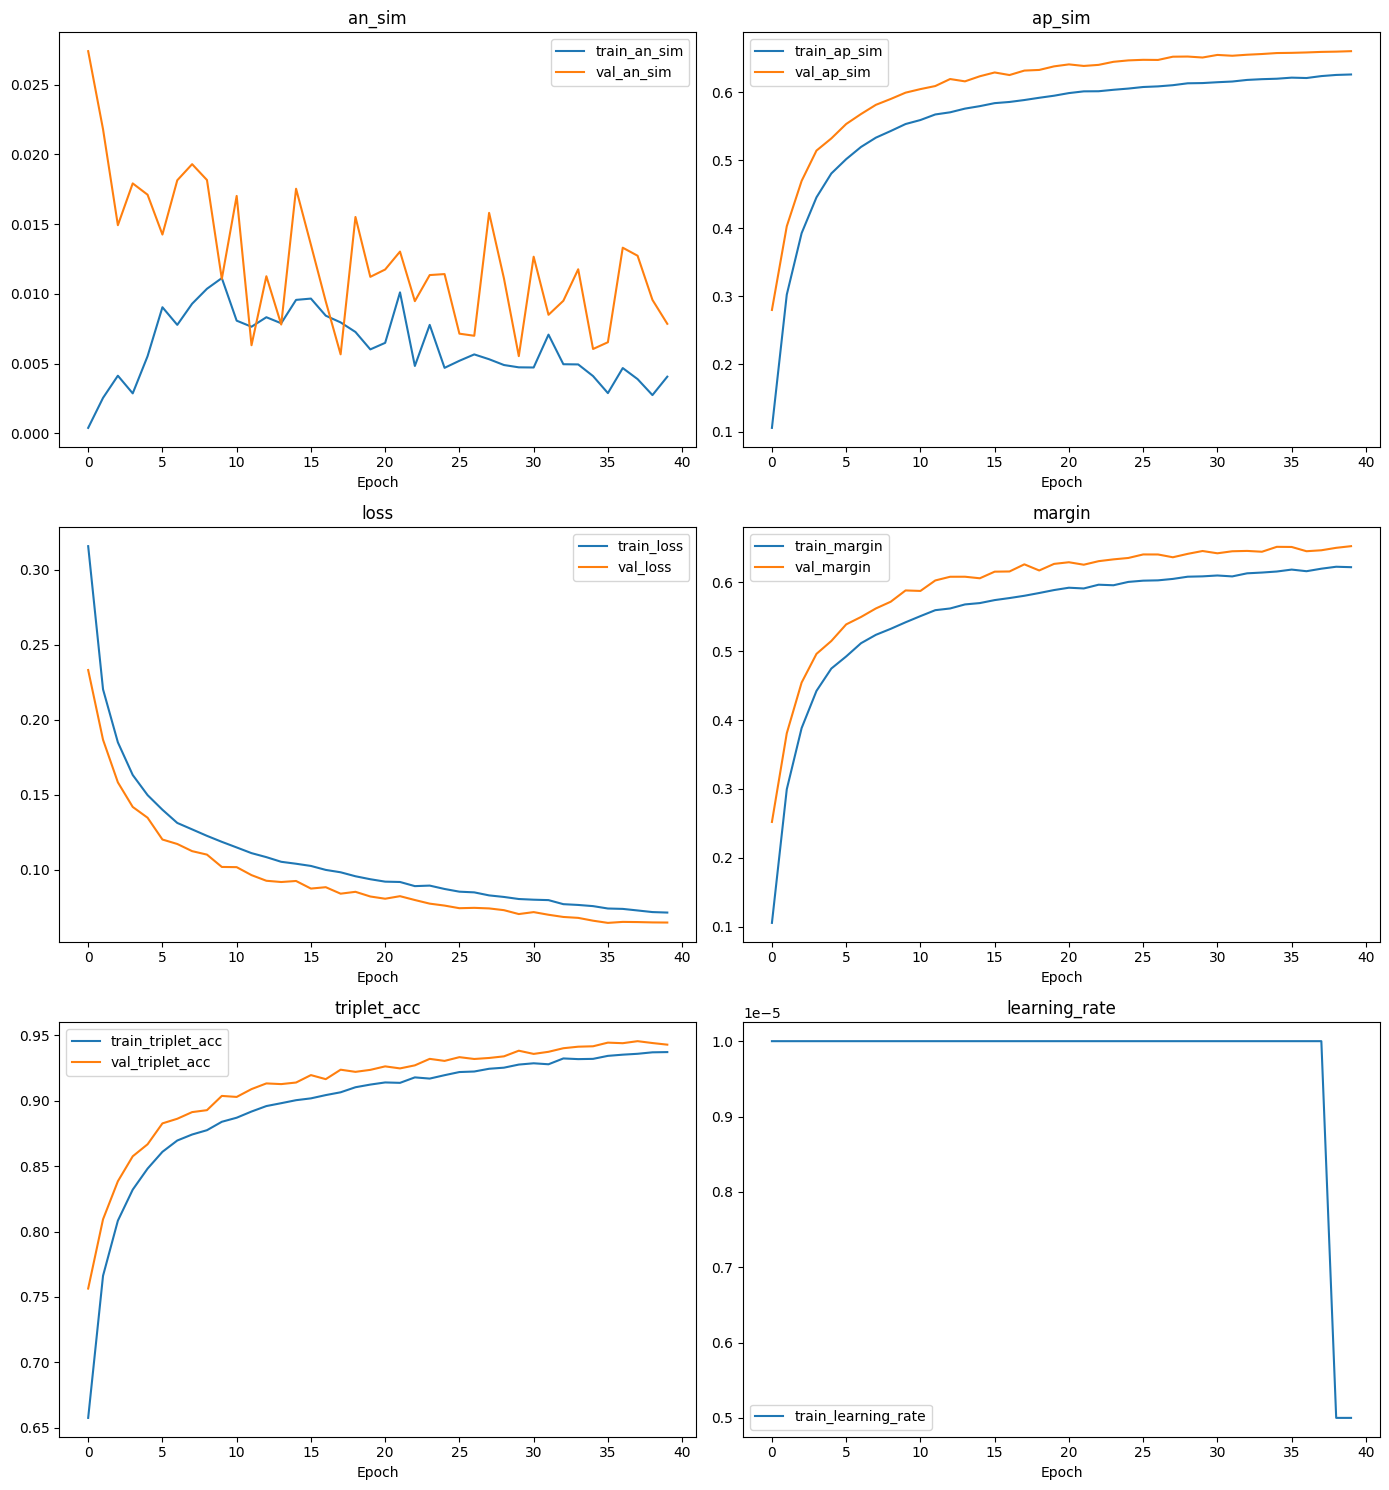

In [38]:
plot_keras_history(history)

In [39]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/siamese_model_204_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/embedding_model_204_{config.current_time}.keras")

In [40]:
save_model(model=trainer, path="./models")

In [41]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments/efficientnet_204")

In [31]:
trainer.siamese_network.load_weights("./models/siamese_model_204_20260407-191343.keras")

In [42]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_val, orient="index", columns=["value"])}")

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 90s 88ms/step - an_sim: 0.0099 - ap_sim: 0.6581 - loss: 0.0667 - margin: 0.6482 - triplet_acc: 0.9405
00:37:19 - efficient_test_204_4 - INFO - 
                value
an_sim       0.009877
ap_sim       0.658100
loss         0.066683
margin       0.648223
triplet_acc  0.940539


In [43]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_test, orient="index", columns=["value"])}")

560/560 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - an_sim: 0.0041 - ap_sim: 0.6992 - loss: 0.0566 - margin: 0.6950 - triplet_acc: 0.9519
00:38:24 - efficient_test_204_4 - INFO - 
                value
an_sim       0.004140
ap_sim       0.699171
loss         0.056586
margin       0.695031
triplet_acc  0.951934


In [32]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [33]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [46]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [47]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

00:38:24 - efficient_test_204_4 - INFO - === Triplet Evaluation Started ===
00:38:24 - efficient_test_204_4 - INFO - === Collecting triplet results ===
00:39:18 - efficient_test_204_4 - INFO - Total triplets collected: 560
00:39:18 - efficient_test_204_4 - INFO - [LOCAL] acc=0.9538 gap=0.6957 error=0.0462 auc=0.9551
00:39:18 - efficient_test_204_4 - INFO - === Computing global metrics ===
00:39:18 - efficient_test_204_4 - INFO - === Global metrics computed ===
00:39:18 - efficient_test_204_4 - INFO - === Triplet Evaluation Finished ===


In [48]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc:.4f}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy:.4f}"
)

00:39:18 - efficient_test_204_4 - INFO - AUC: 0.9551, Accuracy: 0.9538


In [49]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

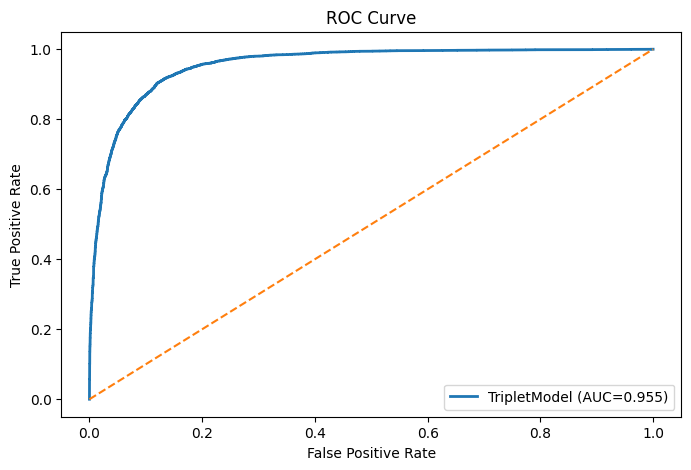

In [50]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

In [51]:
# EER: is a point where FPR ≈ FNR
fnr = 1 - tpr
eer_threshold = thresholds[np.argmin(np.abs(fpr - fnr))]
eer = fpr[np.argmin(np.abs(fpr - fnr))]
logger.info(f"EER: {eer:.4f} at threshold {eer_threshold:.4f}")

00:39:18 - efficient_test_204_4 - INFO - EER: 0.1126 at threshold 0.4232


### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

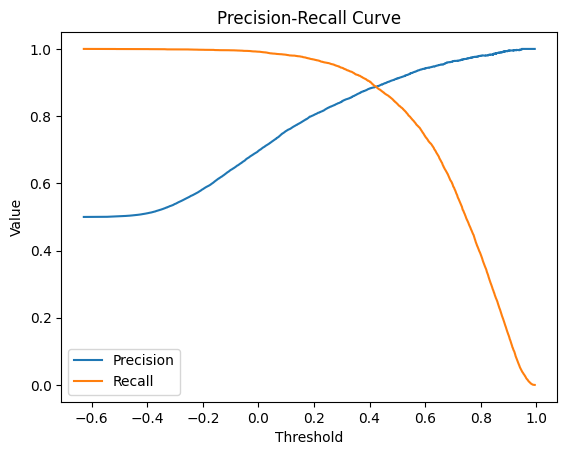

In [52]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

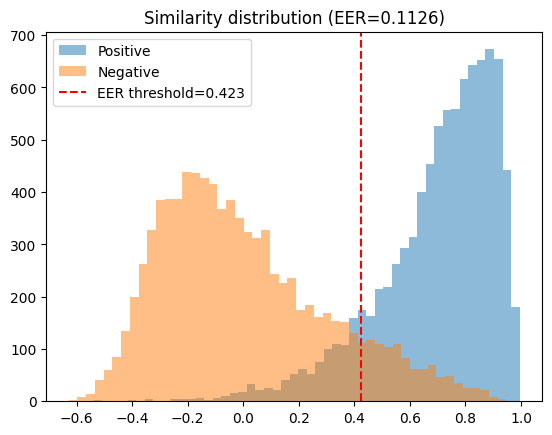

In [53]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(eer_threshold, linestyle='--', color='red', label=f"EER threshold={eer_threshold:.3f}")
plt.legend()
plt.title(f"Similarity distribution (EER={eer:.4f})")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

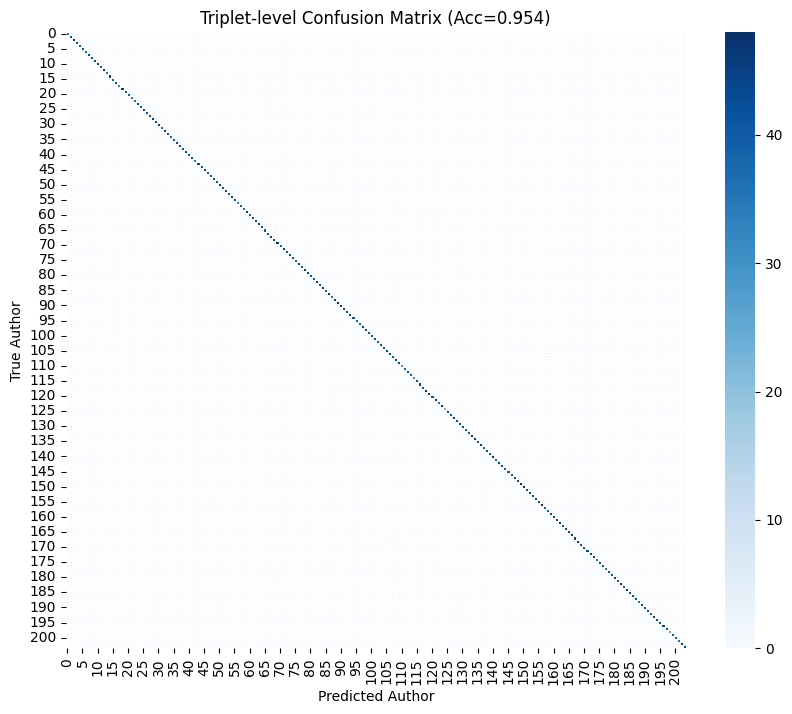

In [54]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

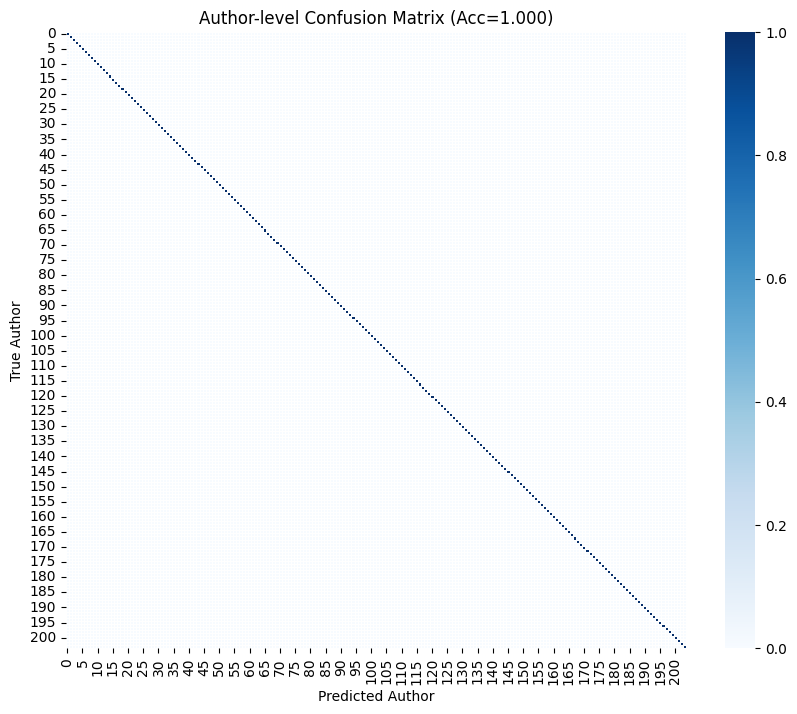

In [55]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

**Comparison**

While the triplet-level matrix evaluates local decision quality, the author-level matrix reflects global identification performance.

Together, they provide a comprehensive understanding of both the embedding quality and the consistency of writer discrimination.

In [56]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,1.007378,36,1.000000,1.000000
1,1,1,1.0,0.767239,42,0.872561,0.872561
2,2,2,1.0,0.911924,47,0.949344,0.949344
3,3,3,1.0,0.672565,45,0.822318,0.822318
4,4,4,1.0,0.739622,41,0.857905,0.857905
...,...,...,...,...,...,...,...
199,199,199,1.0,0.887163,40,0.936203,0.936203
200,200,200,1.0,0.602120,40,0.784934,0.784934
201,201,201,1.0,0.628884,36,0.799138,0.799138
202,202,202,1.0,0.832918,45,0.907416,0.907416


In [34]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [35]:
display_generator_info(val_gen)

11:29:58 - efficient_test_204_4 - INFO - Generator: DataGenerator
11:29:58 - efficient_test_204_4 - INFO - Number of samples: 32223
11:29:58 - efficient_test_204_4 - INFO - Batch size: 32
11:29:58 - efficient_test_204_4 - INFO - Steps per epoch: 1007
11:29:58 - efficient_test_204_4 - INFO - Shape: (180, 360)
11:29:58 - efficient_test_204_4 - INFO - Number of authors: 204


In [36]:
display_generator_info(test_gen)

11:30:00 - efficient_test_204_4 - INFO - Generator: DataGenerator
11:30:00 - efficient_test_204_4 - INFO - Number of samples: 8946
11:30:00 - efficient_test_204_4 - INFO - Batch size: 16
11:30:00 - efficient_test_204_4 - INFO - Steps per epoch: 560
11:30:00 - efficient_test_204_4 - INFO - Shape: (180, 360)
11:30:00 - efficient_test_204_4 - INFO - Number of authors: 204


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [37]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [38]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [39]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [63]:
val_gen_results = emb_evaluator.evaluate(val_gen)

00:39:20 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
00:39:20 - efficient_test_204_4 - INFO - Extracting embeddings from the model
00:39:20 - efficient_test_204_4 - INFO - Processing 1007 batches to extract embeddings
00:46:19 - efficient_test_204_4 - INFO - Extracted embeddings for 32223 samples
00:46:19 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(32223, 224)
00:46:19 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
00:46:19 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


00:47:07 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
00:47:07 - efficient_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
00:47:07 - efficient_test_204_4 - INFO - Applying strategy: 1nn
00:47:13 - efficient_test_204_4 - INFO - Applying aggregator: patch
00:47:13 - efficient_test_204_4 - INFO - Applying aggregator: vote
00:47:13 - efficient_test_204_4 - INFO - Applying aggregator: score
00:47:13 - efficient_test_204_4 - INFO - patch acc=0.4576Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
00:47:13 - efficient_test_204_4 - INFO - Applying strategy: mean
00:51:31 - efficient_test_204_4 - INFO - Applying aggregator: patch
00:51:31 - efficient_test_204_4 - INFO - Applying aggregator: vote
00:51:31 - efficient_test_204_4 - INFO - Applying aggregator: score
00:51:31 - efficient_test_204_4 - INFO - patch acc=0.3702Strategy 'mean' results: , vote acc=0.6422Strategy 'mean' results: , score acc

In [64]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

00:58:24 - efficient_test_204_4 - INFO - Intra distance: 0.2963257133960724
00:58:24 - efficient_test_204_4 - INFO - Inter distance: 0.9865147471427917
00:58:24 - efficient_test_204_4 - INFO - Strategy: 1nn
00:58:24 - efficient_test_204_4 - INFO - Patch accuracy: 0.4576
00:58:24 - efficient_test_204_4 - INFO - Vote accuracy: 1.0000
00:58:24 - efficient_test_204_4 - INFO - Score accuracy: 1.0000
00:58:24 - efficient_test_204_4 - INFO - ----------------------------------------
00:58:24 - efficient_test_204_4 - INFO - Strategy: mean
00:58:24 - efficient_test_204_4 - INFO - Patch accuracy: 0.3702
00:58:24 - efficient_test_204_4 - INFO - Vote accuracy: 0.6422
00:58:24 - efficient_test_204_4 - INFO - Score accuracy: 0.6373
00:58:24 - efficient_test_204_4 - INFO - ----------------------------------------
00:58:24 - efficient_test_204_4 - INFO - Strategy: centroid
00:58:24 - efficient_test_204_4 - INFO - Patch accuracy: 0.4269
00:58:24 - efficient_test_204_4 - INFO - Vote accuracy: 1.0000
00:5

In [40]:
test_gen_results = emb_evaluator.evaluate(
    data_generator=test_gen,
    reducer=UMAPReducer(n_components=3),
)

11:30:37 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
11:30:37 - efficient_test_204_4 - INFO - Extracting embeddings from the model
11:30:38 - efficient_test_204_4 - INFO - Processing 560 batches to extract embeddings
11:34:24 - efficient_test_204_4 - INFO - Extracted embeddings for 8946 samples
11:34:24 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8946, 224)
11:34:24 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:34:24 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


11:34:59 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
11:34:59 - efficient_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
11:34:59 - efficient_test_204_4 - INFO - Applying strategy: 1nn
11:34:59 - efficient_test_204_4 - INFO - Applying aggregator: patch
11:34:59 - efficient_test_204_4 - INFO - Applying aggregator: vote
11:34:59 - efficient_test_204_4 - INFO - Applying aggregator: score
11:34:59 - efficient_test_204_4 - INFO - patch acc=0.7523Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
11:34:59 - efficient_test_204_4 - INFO - Applying strategy: mean
11:35:28 - efficient_test_204_4 - INFO - Applying aggregator: patch
11:35:28 - efficient_test_204_4 - INFO - Applying aggregator: vote
11:35:28 - efficient_test_204_4 - INFO - Applying aggregator: score
11:35:28 - efficient_test_204_4 - INFO - patch acc=0.4519Strategy 'mean' results: , vote acc=0.6912Strategy 'mean' results: , score acc

In [81]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")
logger.info(f"Inter/Intra ratio ≈ {test_gen_results.inter_distance/test_gen_results.intra_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

12:41:19 - efficient_test_204_4 - INFO - Intra distance: 0.35696202516555786
12:41:19 - efficient_test_204_4 - INFO - Inter distance: 0.9935965538024902
12:41:19 - efficient_test_204_4 - INFO - Inter/Intra ratio ≈ 2.783479690551758
12:41:19 - efficient_test_204_4 - INFO - Strategy: 1nn
12:41:19 - efficient_test_204_4 - INFO - Patch accuracy: 0.7523
12:41:19 - efficient_test_204_4 - INFO - Vote accuracy: 1.0000
12:41:19 - efficient_test_204_4 - INFO - Score accuracy: 1.0000
12:41:19 - efficient_test_204_4 - INFO - ----------------------------------------
12:41:19 - efficient_test_204_4 - INFO - Strategy: mean
12:41:19 - efficient_test_204_4 - INFO - Patch accuracy: 0.4519
12:41:19 - efficient_test_204_4 - INFO - Vote accuracy: 0.6912
12:41:19 - efficient_test_204_4 - INFO - Score accuracy: 0.6765
12:41:19 - efficient_test_204_4 - INFO - ----------------------------------------
12:41:19 - efficient_test_204_4 - INFO - Strategy: centroid
12:41:19 - efficient_test_204_4 - INFO - Patch accu

## Probabilistic Interpretation of Voting via Binomial Model

To understand why document-level accuracy reaches near-perfect values despite moderate patch-level accuracy, we can model the aggregation process using a binomial distribution.

### Setup

From the experiment:

- Average number of test patches per author: **n ≈ 44**
- Patch-level accuracy (1NN): **$p \approx 0.75$**

We model the number of correctly classified patches for a given author as:

$${X \sim Binomial \; (n, p)}$$

where:
- $(n)$ = number of patches per author ($\approx 44$)
- $(p)$ = probability a single patch is correctly classified ($\approx 0.75$)

---

### Majority Voting Condition

A correct document-level prediction via voting requires:

$$
X \ge \left\lceil \frac{n}{2} \right\rceil = 22
$$

---

### Expected Value and Variance

$$
\mu = n \cdot p = 44 \cdot 0.75 = 33
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.75 \cdot 0.25} \approx 2.87
$$

---

### Probability of Correct Majority

Using a normal approximation with continuity correction:

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 33}{2.87}\right)
$$

$$
Z \approx -4.01
$$

$$
P(X \ge 22) \approx 0.99997
$$

---

### Interpretation

- Although individual patches are only moderately accurate (`~75%`), the expected number of correct predictions per document is **~33 out of 44**, far above the majority threshold (22).

- The probability of failing the majority vote is therefore extremely small (~0.003%).

---

### Connection to Experimental Results

This explains the observed behavior:

- **Patch accuracy (~0.75)** → moderate classifier strength  
- **Vote accuracy (1.0)** → near-perfect aggregation  

Even weaker strategies such as `centroid` and `top-k` benefit from this effect, though their lower patch accuracy reduces robustness.

---

### Important Caveat

This analysis assumes independence between patches. In practice:

- Patches from the same document are **correlated**
- Errors are not strictly independent

However, since $p \gg 0.5$, the majority vote remains highly reliable even under moderate correlation.

---

### Conclusion

> The binomial model provides a useful theoretical lower bound: with n≈44 patches and p≈0.75, the probability of majority-vote failure is negligible (~0.003%). However, the independence assumption underlying this model is structurally violated — patches from the same document share author, instrument, and writing session, meaning errors tend to be correlated rather than independent.

> In practice, the robustness of vote aggregation is better explained by the quality of the embedding space itself (inter/intra ratio ≈ 2.78). Most authors achieve patch accuracy well above the 0.75 average; confusion is concentrated in a small subset of authors with visually similar styles, as confirmed by log_error_samples. The aggregation resolves this residual noise, but the primary driver of near-perfect document accuracy is embedding separation, not the ensemble effect.

> The binomial framing illustrates why majority voting is stable once p > 0.5, but should not be interpreted as a full explanation of the observed results.

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles or nearby embeddings in the learned space.

> If vote accuracy is high despite patch errors, the model is working correctly — individual patch ambiguity is resolved by majority aggregation.

In [42]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [43]:
viz.set_strategy("1nn")

In [44]:
viz.plot_embeddings()

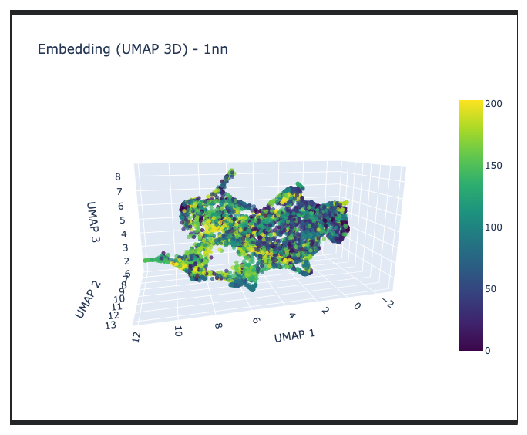

In [72]:
display_output(path="./outputs/embeddings.png")

In [70]:
viz.log_error_samples(n=20)

01:03:56 - efficient_test_204_4 - INFO - Showing 20 error samples:
01:03:56 - efficient_test_204_4 - INFO - [idx=6802] true=lines3_Page_22 pred=lines2_Page_53 (author_id=155 → 118)
01:03:56 - efficient_test_204_4 - INFO - [idx=2504] true=lines1_Page_60 pred=lines1_Page_17 (author_id=57 → 16)
01:03:56 - efficient_test_204_4 - INFO - [idx=6717] true=lines3_Page_20 pred=lines2_Page_57 (author_id=153 → 122)
01:03:56 - efficient_test_204_4 - INFO - [idx=1447] true=lines1_Page_34 pred=lines2_Page_30 (author_id=33 → 95)
01:03:56 - efficient_test_204_4 - INFO - [idx=921] true=lines1_Page_22 pred=lines1_Page_40 (author_id=21 → 37)
01:03:56 - efficient_test_204_4 - INFO - [idx=6355] true=lines3_Page_12 pred=lines2_Page_15 (author_id=145 → 80)
01:03:56 - efficient_test_204_4 - INFO - [idx=6396] true=lines3_Page_13 pred=lines2_Page_31 (author_id=146 → 96)
01:03:56 - efficient_test_204_4 - INFO - [idx=1826] true=lines1_Page_45 pred=lines2_Page_16 (author_id=42 → 81)
01:03:56 - efficient_test_204_4 

In [45]:
viz.plot_centroids()

11:38:23 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.9136 | clusters=13


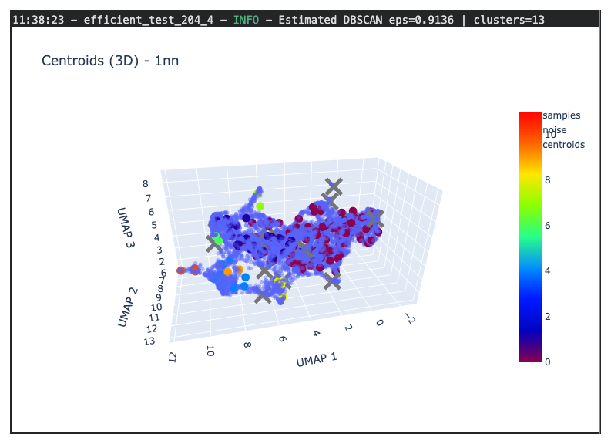

In [73]:
display_output(path="./outputs/embeddings_centroids.png")

In [46]:
one_nn = test_gen_results.strategy_results['1nn']

**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

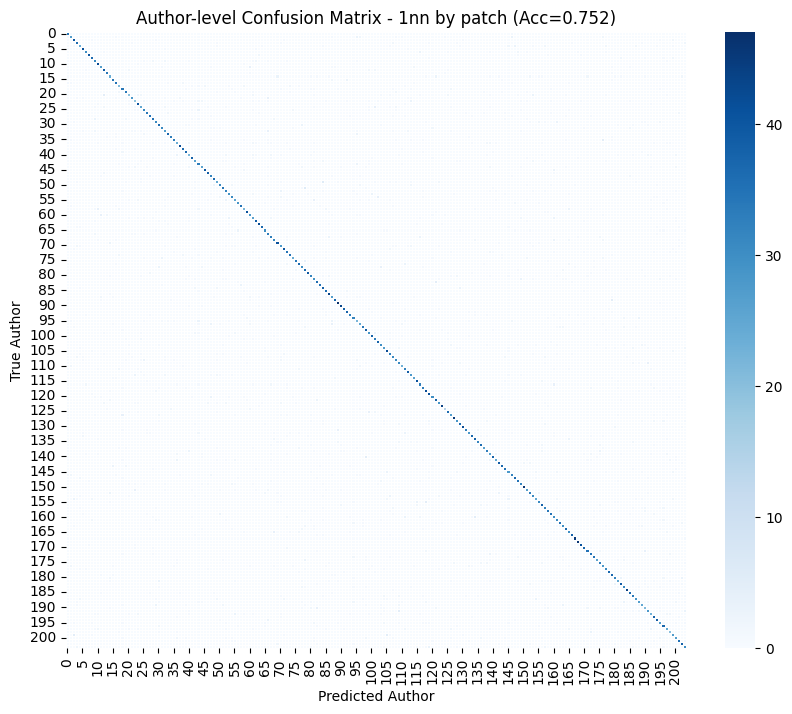

In [47]:
onenn_by_patch = one_nn['patch']
cm_df = build_author_confusion_matrix(
    onenn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

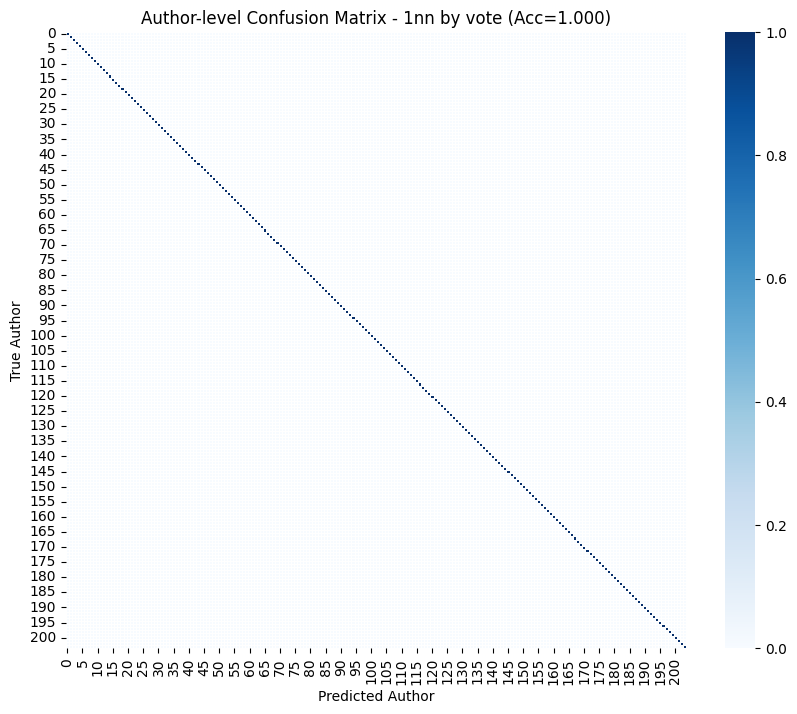

In [48]:
onenn_by_vote = one_nn['vote']
cm_df = build_author_confusion_matrix(
    onenn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by vote")

**Score-level Confusion Matrix**

The score-level aggregation selects the final prediction by accumulating cosine similarity scores across all patches per (author, author_pred) pair, choosing the candidate with the highest total similarity.

Unlike vote-level aggregation, this approach weights predictions by confidence - a small number of high-similarity patches can outweigh a larger number of low-confidence ones. This makes score particulary effective for `1nn` and `topk` strategies, where similarity is a reliable signal.

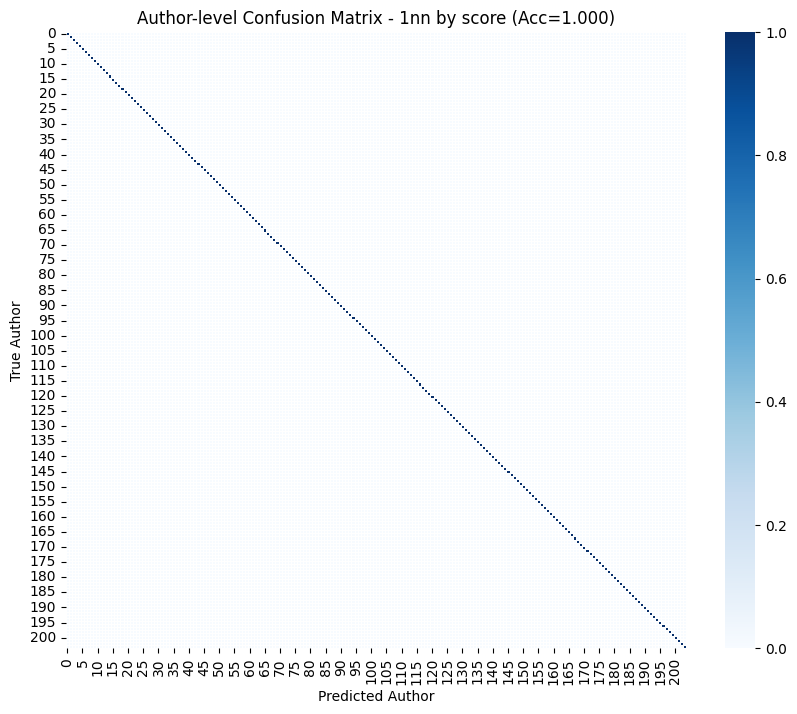

In [49]:
onenn_by_score = one_nn['score']
cm_df = build_author_confusion_matrix(
    onenn_by_score.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by score")

**Comparison**

The comparison between patch-level, vote-level, and score-level confusion matrices highlights different aggregation strategies and their trade-offs.

At the patch level, predictions are based on individual image regions and are therefore noisy and often ambiguous.

The vote-level aggregation reduces noise by combining multiple patch predictions through majority voting, improving stability regardless of prediction confidence.

The score-level aggregation replaces frequency with accumulated cosine similarity, favoring predictions supported by high-confidence matches over predictions supported by sheer count. This leads to stronger performance in neighbor-based strategies (1nn, topk), where similarity is a direct quality measure. For representation-based strategies (mean, centroid), vote-level aggregation can be equally or more effective.

No single aggregation level dominates universally — the optimal choice depends on the strategy used.

In [50]:
viz.set_strategy("topk")

In [51]:
viz.log_error_samples(n=20)

11:39:34 - efficient_test_204_4 - INFO - Showing 20 error samples:
11:39:34 - efficient_test_204_4 - INFO - [idx=4938] true=lines2_Page_48 pred=lines2_Page_47 (author_id=113 → 112)
11:39:34 - efficient_test_204_4 - INFO - [idx=2163] true=lines1_Page_52 pred=lines1_Page_05 (author_id=49 → 4)
11:39:34 - efficient_test_204_4 - INFO - [idx=329] true=lines1_Page_08 pred=lines3_Page_36 (author_id=7 → 169)
11:39:34 - efficient_test_204_4 - INFO - [idx=5599] true=lines2_Page_63 pred=lines2_Page_54 (author_id=128 → 119)
11:39:34 - efficient_test_204_4 - INFO - [idx=643] true=lines1_Page_15 pred=lines2_Page_04 (author_id=14 → 69)
11:39:34 - efficient_test_204_4 - INFO - [idx=1178] true=lines1_Page_28 pred=lines1_Page_29 (author_id=27 → 28)
11:39:34 - efficient_test_204_4 - INFO - [idx=6393] true=lines3_Page_13 pred=lines2_Page_22 (author_id=146 → 87)
11:39:34 - efficient_test_204_4 - INFO - [idx=1414] true=lines1_Page_33 pred=lines2_Page_01 (author_id=32 → 66)
11:39:34 - efficient_test_204_4 - I

In [78]:
topk = test_gen_results.strategy_results['topk']

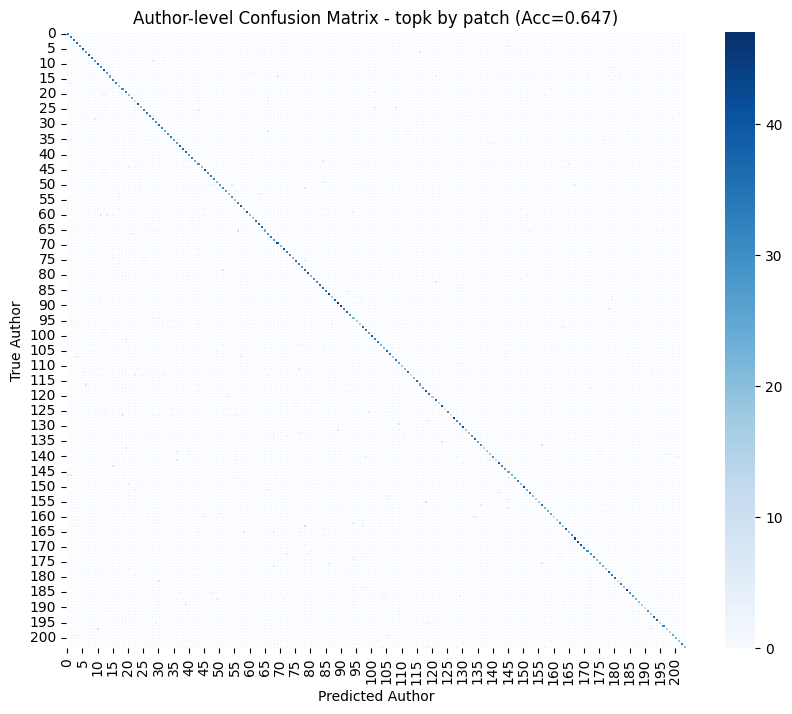

In [79]:
topk_by_patch = topk['patch']
cm_df = build_author_confusion_matrix(
    topk_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by patch")

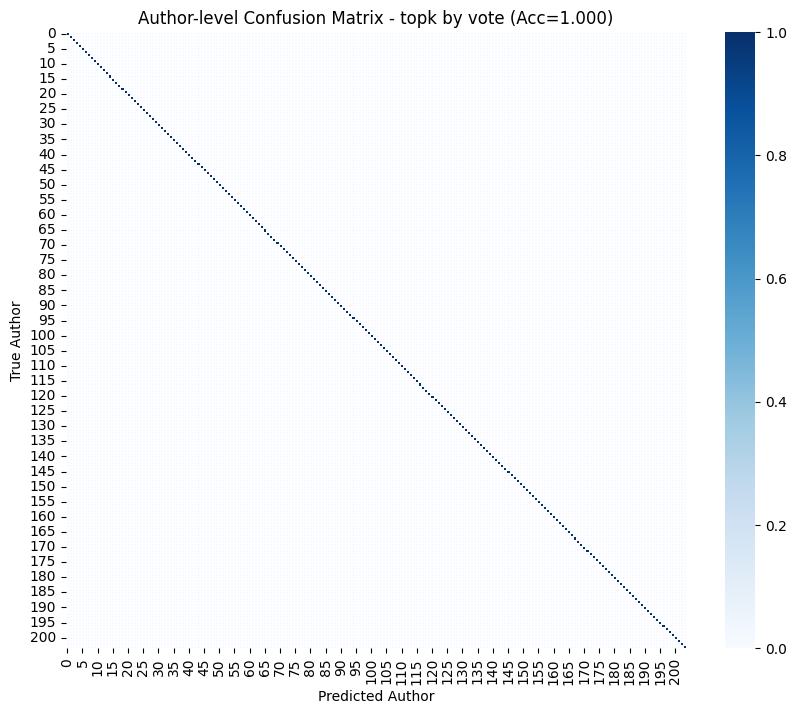

In [80]:
topk_by_vote = topk['vote']
cm_df = build_author_confusion_matrix(
    topk_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by vote")

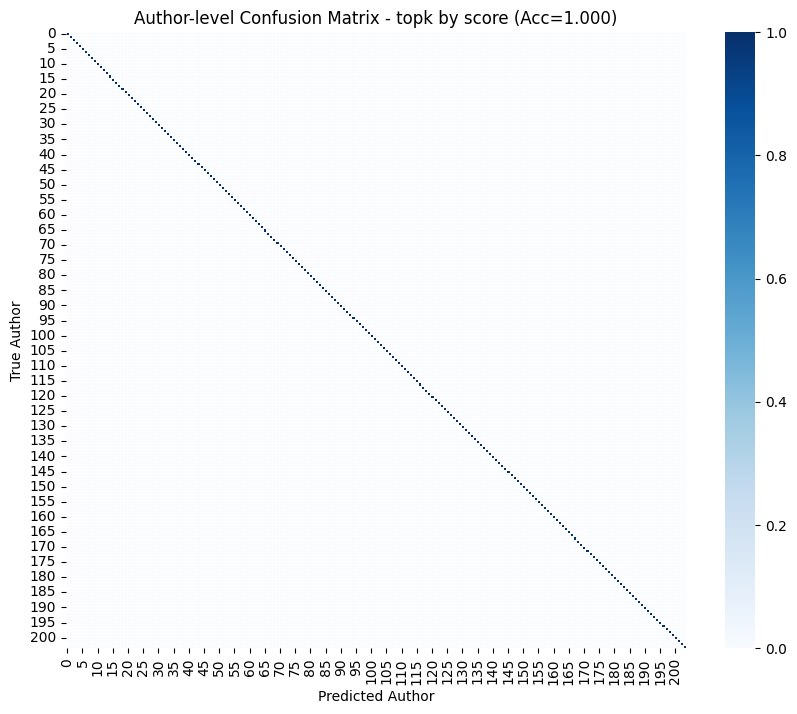

In [81]:
topk_by_score = topk['score']
cm_df = build_author_confusion_matrix(
    topk_by_score.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by score")

In [52]:
viz.plot_centroids([0, 1])

11:40:09 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.9136 | clusters=13


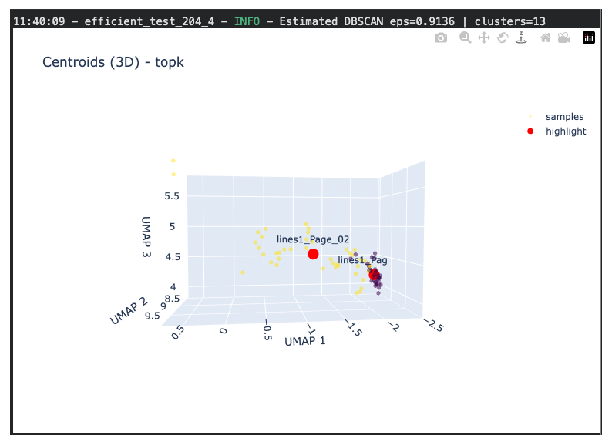

In [74]:
display_output(path="./outputs/embeddings_sample_centroids_1.png")

In [53]:
viz.plot_centroids([0, 203])

11:40:53 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.9136 | clusters=13


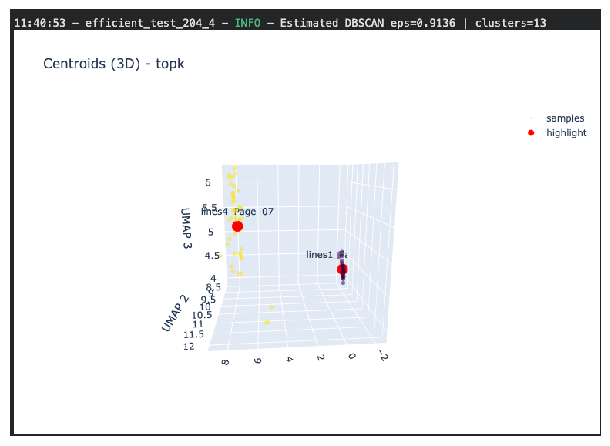

In [75]:
display_output(path="./outputs/embeddings_sample_centroids_2.png")

## Unseen Author Evaluation

So far, all evaluations have been performed on authors the model was trained on (**closed-set** evaluation).

This section evaluates the model on **completely unseen authors** — identities never seen during training.

**Why this matters:**
A metric learning model that only works on known identities has limited practical value.
True generalization means the learned embedding space transfers to new identities —
patches from the same unseen author should still cluster together, and patches from different unseen authors should remain apart.

**Setup:**
- Model trained on authors `0–203`
- Evaluated on authors `204–406` (never seen during training)
- No retraining or fine-tuning — same model, same weights

> This is the most demanding test of the system: if vote accuracy remains high on unseen authors, the model has learned a general representation of handwriting style, not a memorization of known identities.


In [54]:
unseen_train, unseen_val, unseen_test = loader.build(
    authors=range(204, 407),
    validation_fraction=config.training.val_ratio,
)

11:41:47 - efficient_test_204_4 - INFO - Total patches selected: 124645
11:41:47 - efficient_test_204_4 - INFO - Train: 93483 | Val: 31162 | Test: 8722
11:41:47 - efficient_test_204_4 - INFO - Avg non_test patches per author: 614.01 | Min: 84 | Max: 982
11:41:47 - efficient_test_204_4 - INFO - Avg test patches per author: 42.97 | Min: 14 | Max: 49
11:41:47 - efficient_test_204_4 - INFO - Image shape: (180, 360)
11:41:47 - efficient_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [55]:
unseen_test_gen = DataGenerator(
    split=unseen_test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [56]:
display_generator_info(unseen_test_gen)

11:41:52 - efficient_test_204_4 - INFO - Generator: DataGenerator
11:41:52 - efficient_test_204_4 - INFO - Number of samples: 8722
11:41:52 - efficient_test_204_4 - INFO - Batch size: 16
11:41:52 - efficient_test_204_4 - INFO - Steps per epoch: 546
11:41:52 - efficient_test_204_4 - INFO - Shape: (180, 360)
11:41:52 - efficient_test_204_4 - INFO - Number of authors: 203


In [57]:
unseen_test_gen_results = emb_evaluator.evaluate(
    data_generator=unseen_test_gen,
    reducer=UMAPReducer(n_components=3),
)

11:41:58 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
11:41:58 - efficient_test_204_4 - INFO - Extracting embeddings from the model
11:41:58 - efficient_test_204_4 - INFO - Processing 546 batches to extract embeddings
11:45:38 - efficient_test_204_4 - INFO - Extracted embeddings for 8722 samples
11:45:38 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8722, 224)
11:45:38 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:45:38 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



11:45:53 - efficient_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
11:45:53 - efficient_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
11:45:53 - efficient_test_204_4 - INFO - Applying strategy: 1nn
11:45:53 - efficient_test_204_4 - INFO - Applying aggregator: patch
11:45:53 - efficient_test_204_4 - INFO - Applying aggregator: vote
11:45:53 - efficient_test_204_4 - INFO - Applying aggregator: score
11:45:53 - efficient_test_204_4 - INFO - patch acc=0.7269Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
11:45:53 - efficient_test_204_4 - INFO - Applying strategy: mean
11:46:21 - efficient_test_204_4 - INFO - Applying aggregator: patch
11:46:21 - efficient_test_204_4 - INFO - Applying aggregator: vote
11:46:21 - efficient_test_204_4 - INFO - Applying aggregator: score
11:46:21 - efficient_test_204_4 - INFO - patch acc=0.3465Strategy 'mean' results: , vote acc=0.5911Strategy 'mean' results: , score acc

In [82]:
logger.info(f"Intra distance: {unseen_test_gen_results.intra_distance}")
logger.info(f"Inter distance: {unseen_test_gen_results.inter_distance}")
logger.info(f"Inter/Intra ratio ≈ {unseen_test_gen_results.inter_distance/unseen_test_gen_results.intra_distance}")

for strategy_name, agg_results in unseen_test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

12:42:48 - efficient_test_204_4 - INFO - Intra distance: 0.2950529456138611
12:42:48 - efficient_test_204_4 - INFO - Inter distance: 0.9718447327613831
12:42:48 - efficient_test_204_4 - INFO - Inter/Intra ratio ≈ 3.293797731399536
12:42:48 - efficient_test_204_4 - INFO - Strategy: 1nn
12:42:48 - efficient_test_204_4 - INFO - Patch accuracy: 0.7269
12:42:48 - efficient_test_204_4 - INFO - Vote accuracy: 1.0000
12:42:48 - efficient_test_204_4 - INFO - Score accuracy: 1.0000
12:42:48 - efficient_test_204_4 - INFO - ----------------------------------------
12:42:48 - efficient_test_204_4 - INFO - Strategy: mean
12:42:48 - efficient_test_204_4 - INFO - Patch accuracy: 0.3465
12:42:48 - efficient_test_204_4 - INFO - Vote accuracy: 0.5911
12:42:48 - efficient_test_204_4 - INFO - Score accuracy: 0.5813
12:42:48 - efficient_test_204_4 - INFO - ----------------------------------------
12:42:48 - efficient_test_204_4 - INFO - Strategy: centroid
12:42:48 - efficient_test_204_4 - INFO - Patch accur

## Probabilistic Interpretation of Voting

To explain the near-perfect document-level accuracy, we model the voting mechanism using a binomial distribution.

For the `unseen` setting:

$$
X \sim \text{Binomial}(n = 44, \, p = 0.7269)
$$

$$
\mu = np = 44 \cdot 0.7269 \approx 31.98
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.7269 \cdot 0.2731} \approx 2.96
$$

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 31.98}{2.96}\right) \approx 0.999
$$

Thus, even for unseen authors, the probability of correct majority remains extremely high, which is consistent with the observed vote accuracy of 1.0 and score accuracy of 1.0.

---

Additionally, the embedding space maintains strong separability in the unseen setting:

$$
\text{Intra distance} \approx 0.295, \quad
\text{Inter distance} \approx 0.972, \quad
\frac{\text{Inter}}{\text{Intra}} \approx 3.29
$$

This large margin between intra-class and inter-class distances supports robust nearest-neighbor decisions.

---

However, this analysis assumes independence between patches. In practice, patches extracted from the same document are correlated.

Nevertheless, since $p \gg 0.5$, the majority vote remains highly reliable even under moderate correlation.

### Unseen Results Summary

The drop in patch accuracy (~5pp) is expected — the model was not trained on these identities.
The fact that **vote accuracy remains 100%** confirms that the embedding space generalizes:
individual patch ambiguity is resolved by aggregation, even for completely new authors.


In [59]:
unseen_viz = EmbeddingVisualizer(
    report=unseen_test_gen_results,
    logger=logger,
    split=unseen_test,
)
unseen_viz.set_strategy("1nn")

In [60]:
unseen_viz.plot_embeddings()

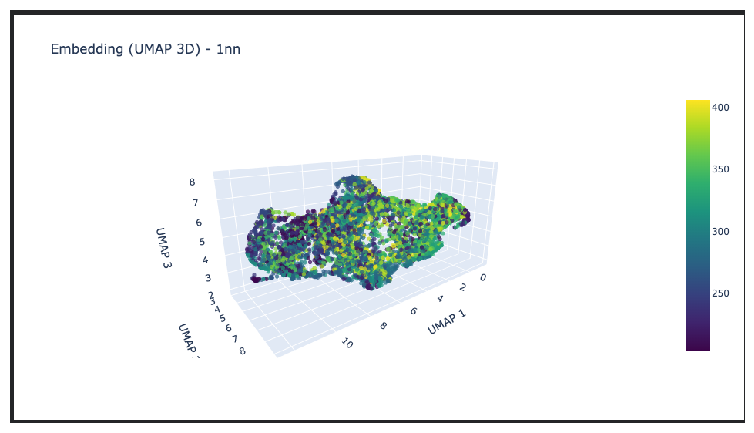

In [76]:
display_output(path="./outputs/unseen_embeddings.png")

In [61]:
unseen_viz.plot_centroids()

12:20:49 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.7680 | clusters=21


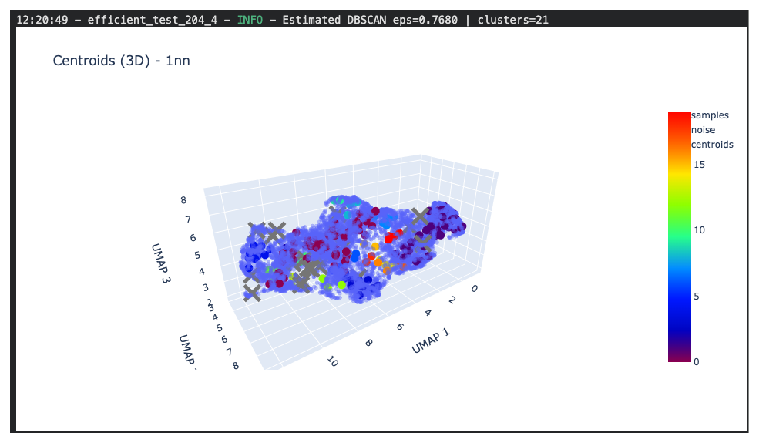

In [77]:
display_output(path="./outputs/unseen_embeddings_centroids.png")

In [62]:
unseen_1nn = unseen_test_gen_results.strategy_results['1nn']

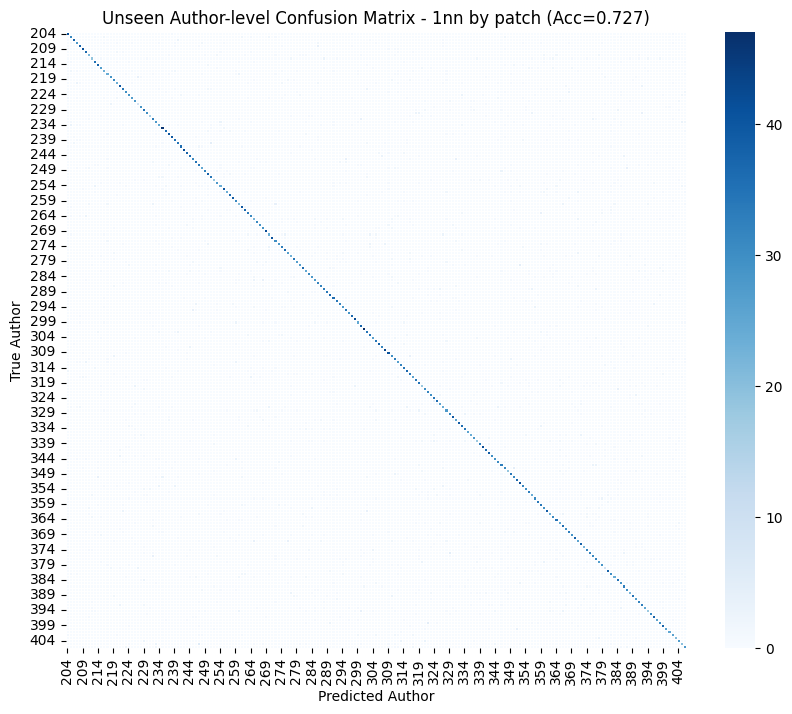

In [63]:
unseen_1nn_by_patch = unseen_1nn['patch']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by patch")

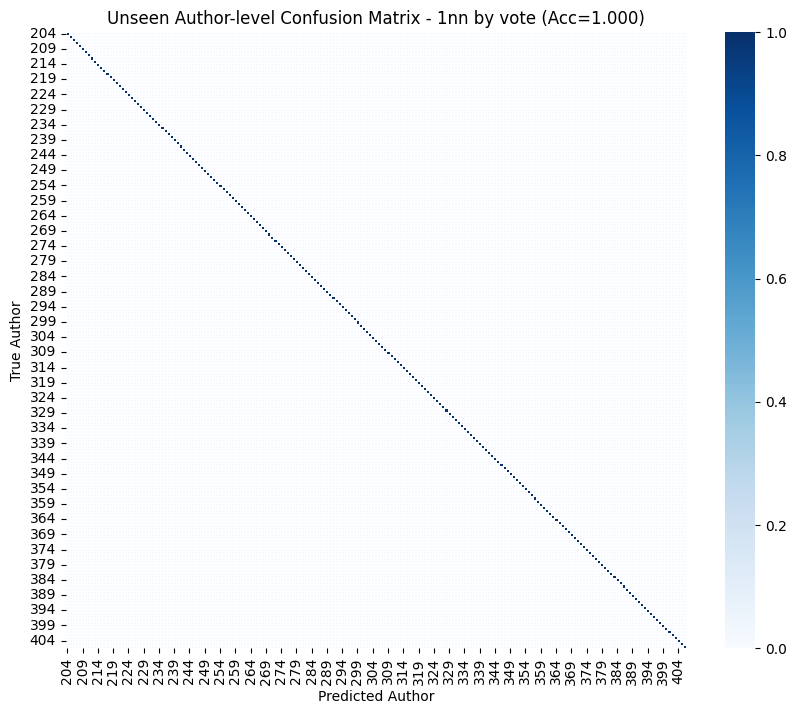

In [64]:
unseen_1nn_by_vote = unseen_1nn['vote']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by vote")

In [65]:
unseen_viz.set_strategy("topk")
unseen_topk = unseen_test_gen_results.strategy_results['topk']

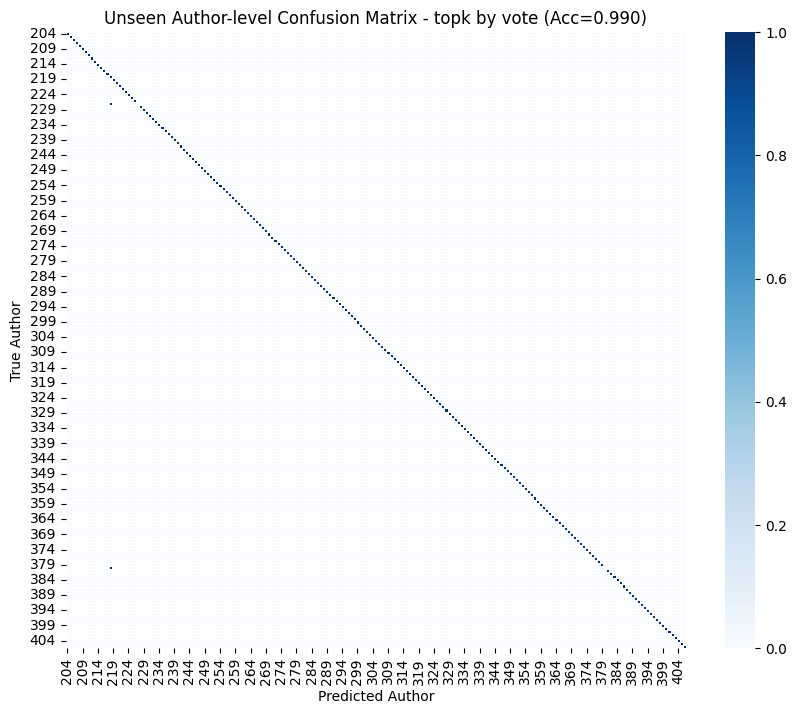

In [66]:
unseen_topk_by_vote = unseen_topk['vote']
cm_df = build_author_confusion_matrix(
    unseen_topk_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - topk by vote")

In [67]:
unseen_viz.plot_centroids([204, 406])

12:23:18 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.7680 | clusters=21


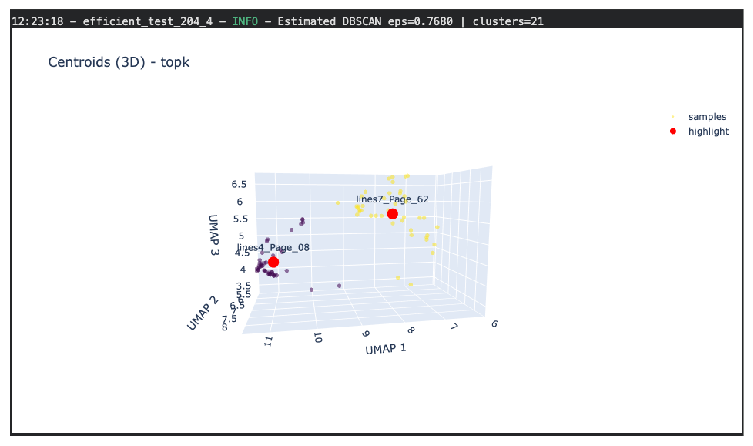

In [78]:
display_output(path="./outputs/unseen_embeddings_sample_1.png")

In [68]:
topk_data = unseen_topk_by_vote.data
topk_error_data = topk_data[topk_data['correct'] == False]
topk_error_data[['author', 'author_pred']]

,author,author_pred
23,227,218
176,380,218


### Error Analysis — Unseen Authors

The following pairs are the authors misclassified by the centroid strategy.
Each pair is visualized in UMAP space to understand why the model confuses them.

These errors are particularly informative in the unseen setting:
since the model never saw these authors, confusions reveal genuine similarity
in handwriting style rather than artifacts of training.

In [69]:
unseen_viz.plot_centroids([227, 218])

12:25:12 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.7680 | clusters=21


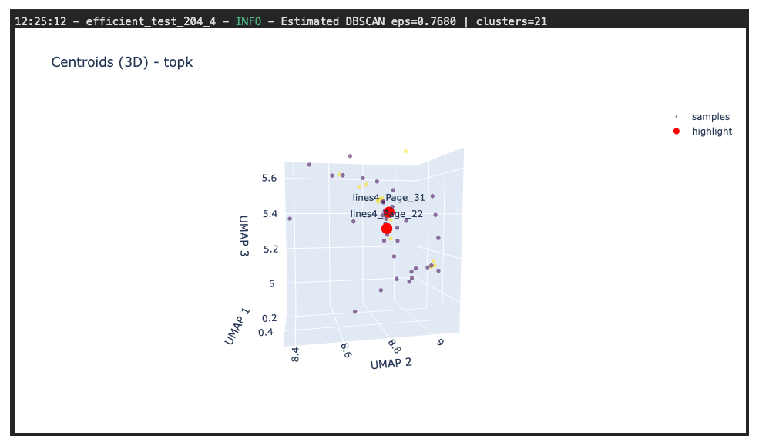

In [79]:
display_output(path="./outputs/unseen_embeddings_sample_errors_1.png")

In [70]:
unseen_viz.plot_centroids([380, 218])

12:26:22 - efficient_test_204_4 - INFO - Estimated DBSCAN eps=0.7680 | clusters=21


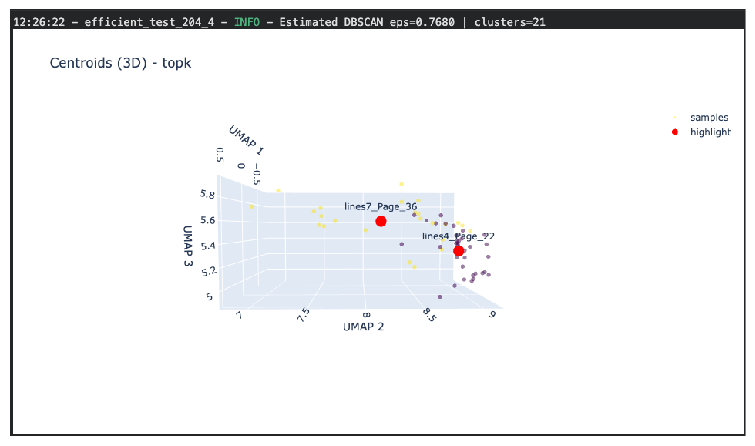

In [80]:
display_output(path="./outputs/unseen_embeddings_sample_errors_2.png")